# Forced Oscillations of Coupled Oscillators
## Using the `ResOSc` package

This notebook demonstrates the **ResOSc** (Resonant Oscillator Simulator for Coupled Systems) package. It sets up a system of $n$ coupled oscillators, solves for the normal modes, introduces damped forced oscillations, visualizes the mode shapes, and analyzes optimal observables for monitoring all resonant frequencies simultaneously.

The package uses **LAPACK** for eigenvalue decomposition. Documentation: [LAPACK dgeevx](https://www.netlib.org/lapack/explore-html/d1/d2a/group__geevx_ga11536a206dc641c6a59cab916bb1c721.html).

# Import the ResOSc Package

In [ ]:
import numpy as np

from ResOSc import CoupledSystem # type: ignore
from ResOSc.plotting import setup_plot_style, plot_normal_amplitudes, plot_spatial_amplitudes   # type: ignore
from ResOSc.modes import mode_shapes_stem, mode_shapes_heatmap  # type: ignore
from ResOSc.observables import (coupling_heatmap, find_minimum_observables,     # type: ignore
                                 optimize_observable, compare_observables)

# Setting Up the System
## User Interface — Feel free to change any constants here!

In [ ]:
# Create a system of 10 coupled oscillators
sys = CoupledSystem(n=10)

# Individual masses
sys.set_masses([0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90])

# Spring constants: wall springs (k_ii) and coupling springs (k_{i,i+1})
sys.set_springs(
    wall=[1.2, 1.3, 1.4, 0.2, 2.2, 1.2, 1.0, 2.0, 2.4, 1.2], # len = n
    coupling=[0.1, 0.2, 0.4, 0.9, 1.3, 1.0, 1.4, 3.5, 2.1],  # len = n - 1
)

# Damping ratio (dimensionless). Set to 0 for no damping.
sys.set_damping(gamma=0.01)

# Experiment parameters
L  = 1      # Length of the apparatus
h0 = 1      # Strain amplitude

# Save plots to PDF? Set to a folder name to save, or None to skip.
save_plots = 'figures-used'  # e.g. 'figures', 'plots', or None

In [ ]:
import os

def fig_path(name):
    """Return the full path for saving a figure, or None if saving is disabled."""
    if save_plots is None:
        return None
    os.makedirs(save_plots, exist_ok=True)
    return os.path.join(save_plots, name)

## Inspect the System

In [ ]:
print(f'Oscillator masses:\n {sys.M}\n')
print(f'Springs matrix:\n {sys.K}')

Oscillator masses:
 [0.45 0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9 ]

Springs matrix:
 [[1.2 0.1 0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.1 1.3 0.2 0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.2 1.4 0.4 0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.4 0.2 0.9 0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.9 2.2 1.3 0.  0.  0.  0. ]
 [0.  0.  0.  0.  1.3 1.2 1.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  1.  1.  1.4 0.  0. ]
 [0.  0.  0.  0.  0.  0.  1.4 2.  3.5 0. ]
 [0.  0.  0.  0.  0.  0.  0.  3.5 2.4 2.1]
 [0.  0.  0.  0.  0.  0.  0.  0.  2.1 1.2]]


# Solving the Eigenvalue Problem

We solve $Hx = {\omega^*}^2 x$ to find the normal frequencies and eigenvectors of the coupled system.

In [ ]:
# Build the dynamical matrix H and solve for eigenvalues/eigenvectors
sys.solve()
sys.compute_forces(L=L, h0=h0)

print(f'Matrix H:\n {np.array2string(sys.H, precision=3, suppress_small=True)}\n')
print(f'Squared normal frequencies:\n {np.array2string(sys.wr, precision=3)}\n')
print(f'Normal frequencies:\n {np.array2string(sys.frequencies, precision=3)}\n')
print(f'Eigenvector matrix A (rows = modes, cols = oscillators):\n {np.array2string(sys.eigenvectors, precision=3, suppress_small=True)}\n')
print(f'Generalized forces on normal modes:\n {np.array2string(sys.q, precision=3)}')

Matrix H:
 [[ 2.889 -0.222  0.     0.     0.     0.     0.     0.     0.     0.   ]
 [-0.2    3.2   -0.4    0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.    -0.364  3.636 -0.727  0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.    -0.667  2.5   -1.5    0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.    -1.385  6.769 -2.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.    -1.857  5.    -1.429  0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.    -1.333  4.533 -1.867  0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.    -1.75   8.625 -4.375  0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.    -4.118  9.412 -2.471]
 [ 0.     0.     0.     0.     0.     0.     0.     0.    -2.333  3.667]]

Squared normal frequencies:
 [13.759  8.42   6.621  4.796  4.019  3.202  2.947  2.749  2.065  1.654]

Normal frequencies:
 [3.709 2.902 2.573 2.19  2.005 1.789 1.717 1.658 1.437 1.286]

Eigenvector matrix A (rows = modes, cols = oscillators):
 [[-0.     0. 

# Normal Mode Shapes

Each normal mode $i$ has an eigenvector $A_i = [A_{i,1}, A_{i,2}, \ldots, A_{i,n}]$ describing the relative displacement of each oscillator. We visualize these mode shapes below.

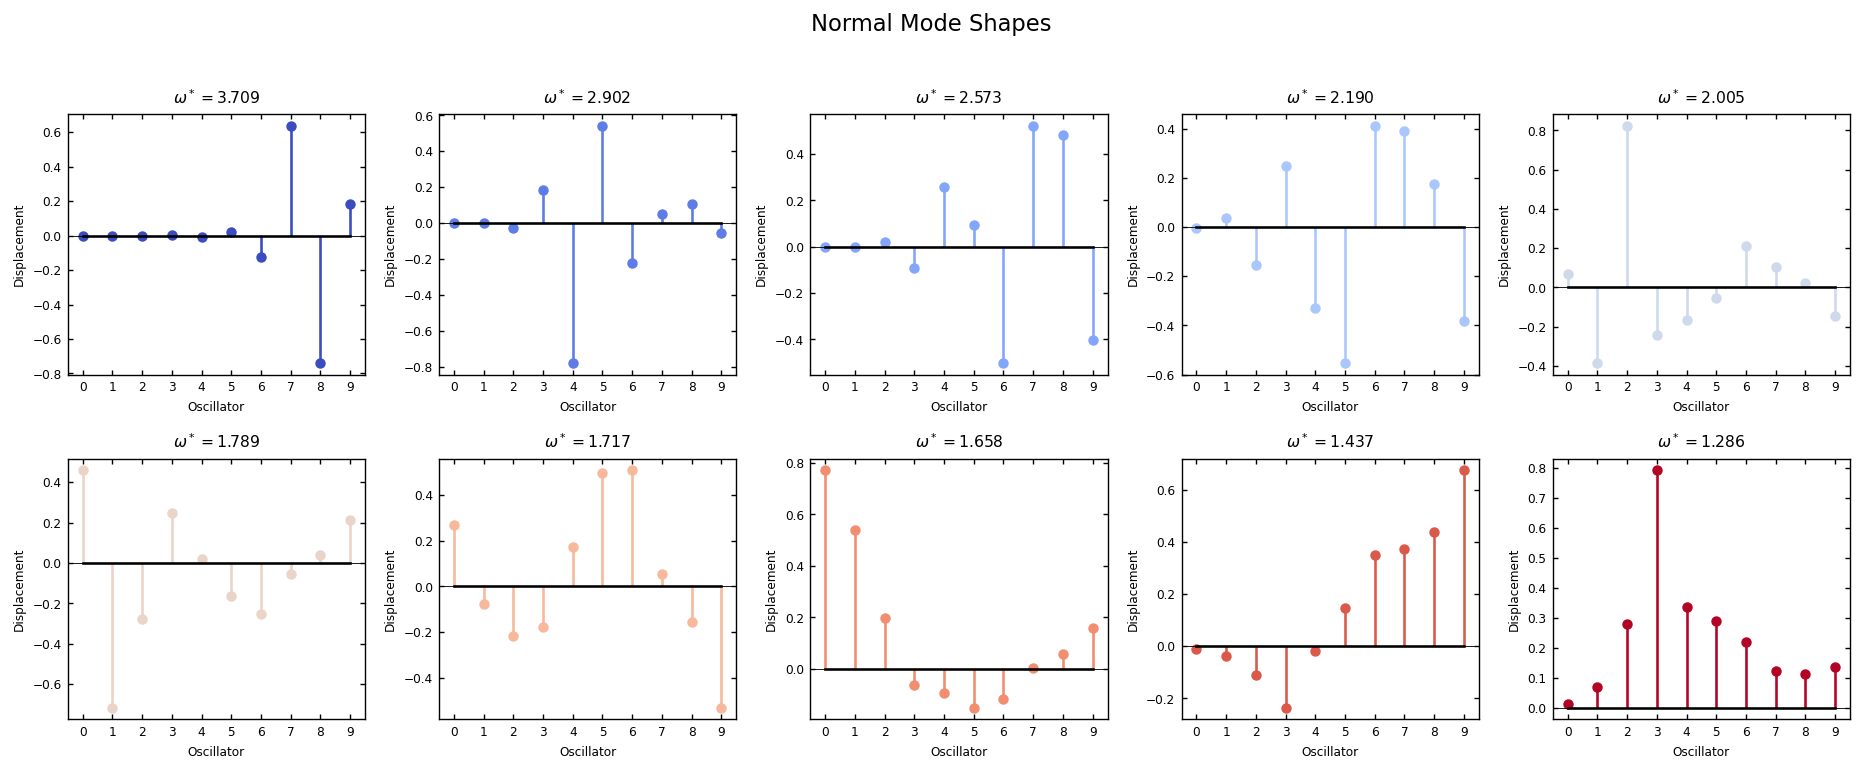

In [ ]:
mode_shapes_stem(sys, savefig=fig_path('mode_shapes_stem.pdf'))

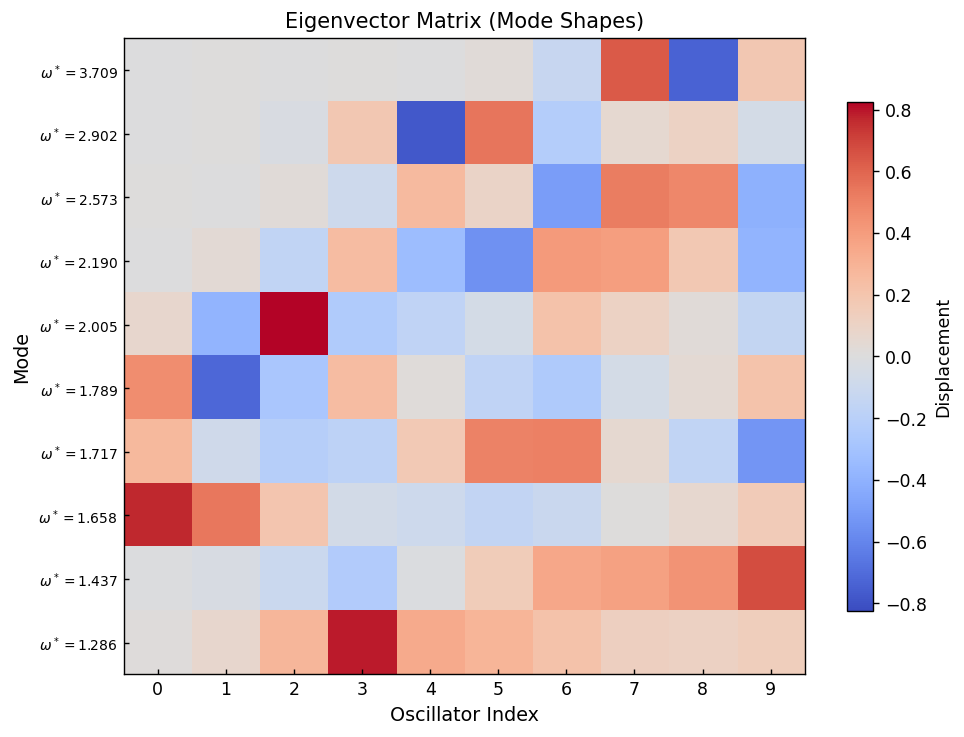

In [ ]:
mode_shapes_heatmap(sys, savefig=fig_path('mode_shapes_heatmap.pdf'))

# Forced Oscillations with Damping

With uniform damping ratio $\gamma$, each normal mode's equation of motion becomes:
$$\ddot{\xi}_i + 2\gamma\omega^*_i\dot{\xi}_i + {\omega^*_i}^2\xi_i = q_i\cos(\omega t)$$

The steady-state amplitude is:
$$|b_i(\omega)| = \frac{q_i}{\sqrt{({\omega^*_i}^2 - \omega^2)^2 + (2\gamma\omega^*_i\omega)^2}}$$

This gives a finite peak at resonance: $b_{i,\text{max}} \approx \frac{|q_i|}{2\gamma{\omega^*_i}^2}$.

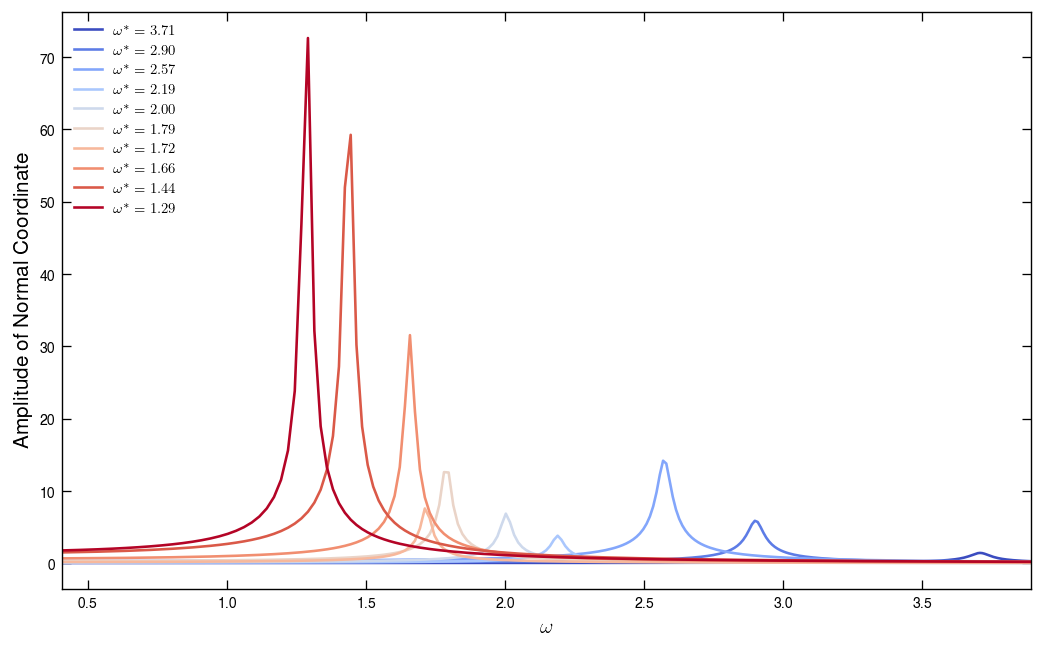

In [ ]:
setup_plot_style()

# Plot amplitudes in normal coordinate space
plot_normal_amplitudes(sys, w_range=(sys.wr.min()*0.10, sys.wr.max()*1.10), savefig=fig_path('normal_amplitudes.pdf'))

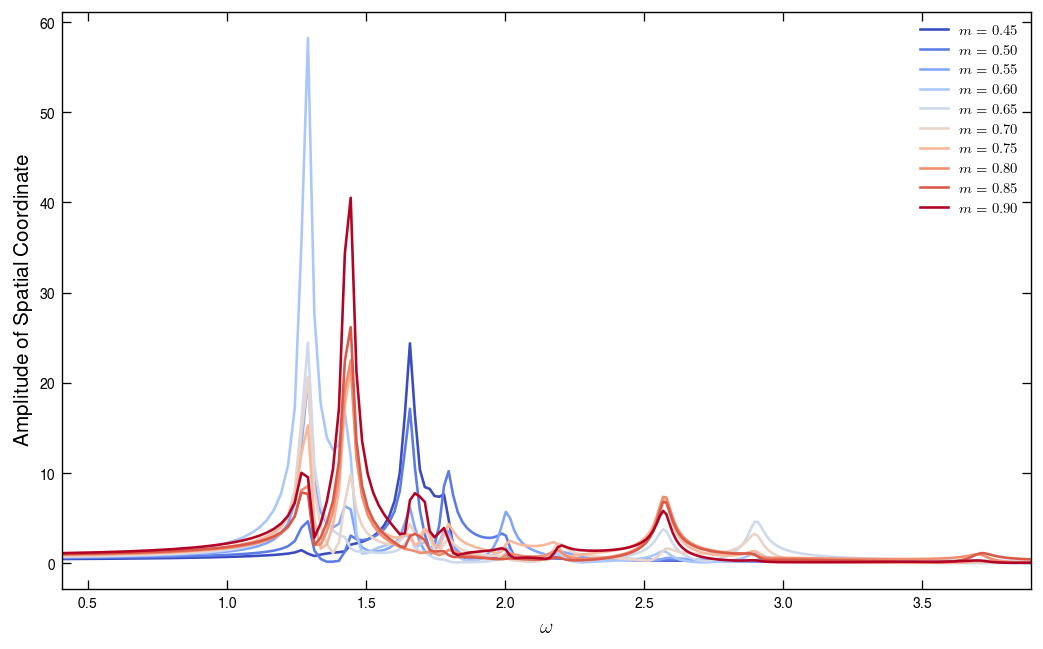

In [ ]:
# Plot amplitudes in spatial coordinate space (per oscillator)
plot_spatial_amplitudes(sys, w_range=(sys.wr.min()*0.10, sys.wr.max()*1.10), savefig=fig_path('spatial_amplitudes.pdf'))

## Peak Sensitivities

The maximum amplitude (sensitivity) of each normal mode to a fixed driving force, determined by the damping ratio $\gamma$:

In [ ]:
peaks = sys.peak_sensitivities()
for i in range(sys.n):
    print(f'Mode {i} (omega*={sys.frequencies[i]:.3f}): b_max = {peaks[i]:.3f}')

Mode 0 (omega*=3.709): b_max = 1.426
Mode 1 (omega*=2.902): b_max = 5.896
Mode 2 (omega*=2.573): b_max = 14.359
Mode 3 (omega*=2.190): b_max = 3.812
Mode 4 (omega*=2.005): b_max = 6.873
Mode 5 (omega*=1.789): b_max = 13.891
Mode 6 (omega*=1.717): b_max = 7.833
Mode 7 (omega*=1.658): b_max = 31.563
Mode 8 (omega*=1.437): b_max = 68.771
Mode 9 (omega*=1.286): b_max = 79.590


# Observable Analysis

An observable is a linear combination of oscillator displacements: $O = \sum_j w_j x_j$. Using $x = \xi A$, the response of observable $O$ to driving at frequency $\omega$ is:
$$O(\omega) = \sum_i c_i \, b_i(\omega), \quad \text{where } c_i = \sum_j w_j A_{ji}$$

The coupling coefficient $c_i$ tells us how strongly observable $O$ responds to mode $i$. For a single-oscillator observable (monitoring oscillator $j$), $c_i = A_{ij}$.

## Coupling Matrix

The heatmap below shows $|C_{j,i}| = |A_{i,j}|$: the coupling strength of each oscillator to each mode.

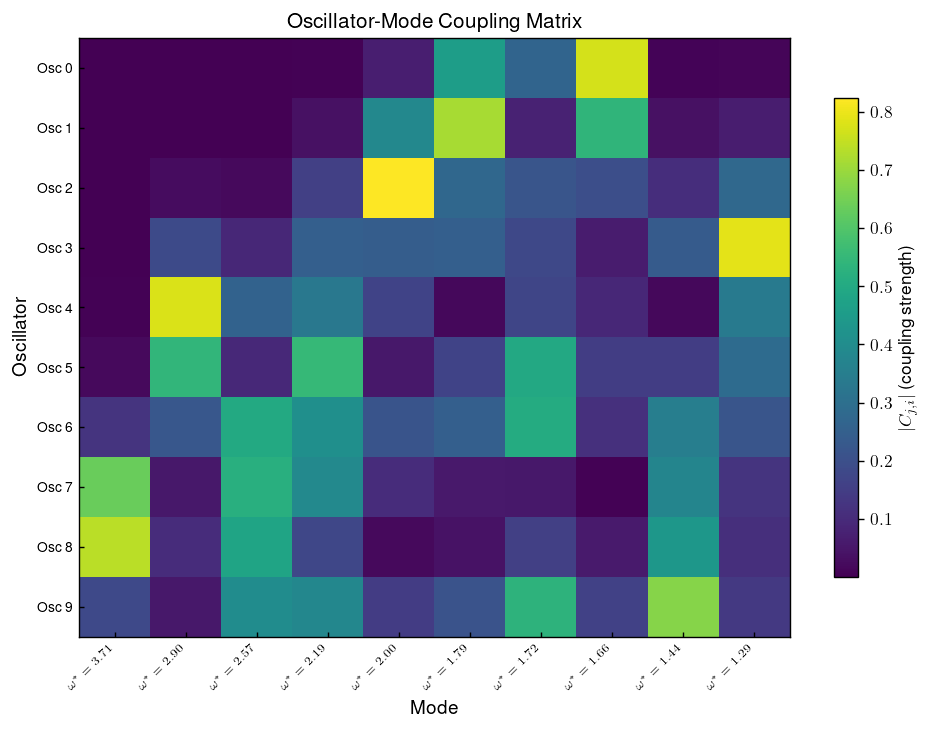

In [ ]:
C = coupling_heatmap(sys, savefig=fig_path('coupling_matrix.pdf'))

## Minimum Number of Observables

The optimization question: can we monitor all $n$ normal modes with fewer than $n$ observables? If a single oscillator couples to all modes ($|c_i| > 0$ for all $i$), one observable suffices.

In [ ]:
result = find_minimum_observables(sys, threshold=1e-2)
print(result['summary'])

Number of oscillators: 10
Number of normal modes: 10
Detection threshold: 1.0e-02

Oscillators that can individually detect ALL modes: [5, 6, 8, 9]
=> A SINGLE observable suffices! Monitor any of these oscillators.

Coverage per oscillator (number of modes detected):
  Oscillator 0: 5/10 modes
  Oscillator 1: 7/10 modes
  Oscillator 2: 9/10 modes
  Oscillator 3: 9/10 modes
  Oscillator 4: 9/10 modes
  Oscillator 5: 10/10 modes
  Oscillator 6: 10/10 modes
  Oscillator 7: 9/10 modes
  Oscillator 8: 10/10 modes
  Oscillator 9: 10/10 modes


# Optimal Observable

Even if a single observable can detect all modes, its sensitivity to different modes may vary widely. We optimize the weight vector $\mathbf{w}$ (with $\|\mathbf{w}\|=1$) to maximize the worst-case sensitivity:
$$\max_{\mathbf{w}} \min_i S_i(\mathbf{w}), \quad S_i(\mathbf{w}) = |c_i| \cdot b_{i,\text{max}}$$

We compare the best single-oscillator observable against the optimized linear combination.

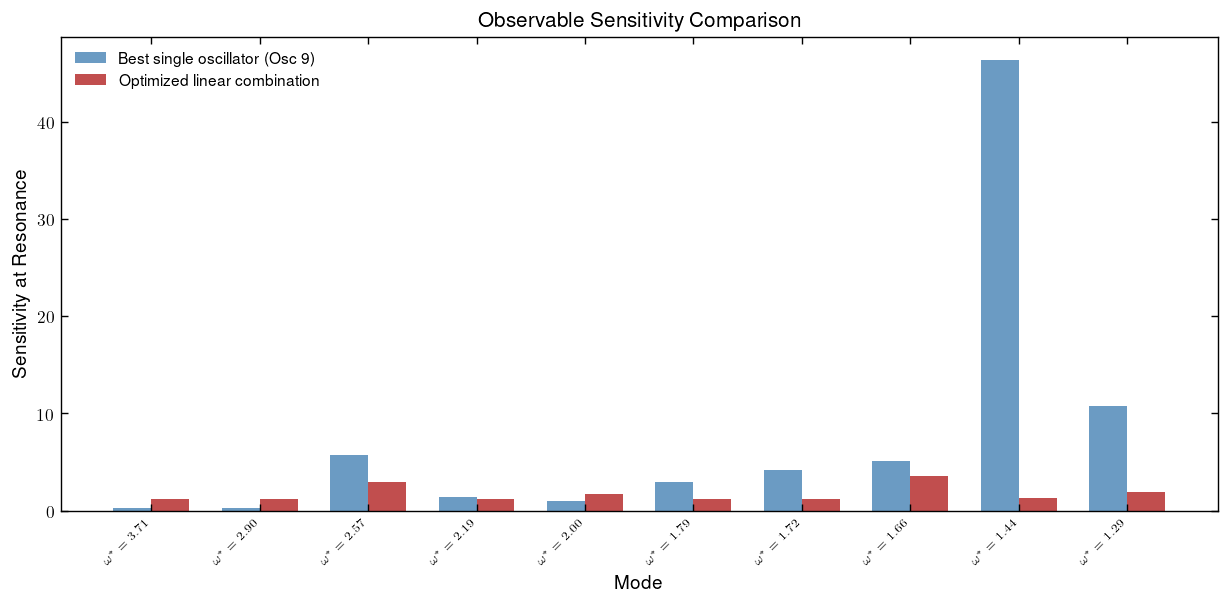


Best single oscillator: Oscillator 9
  Worst-case sensitivity: 0.2578

Optimized weights: [ 0.0374 -0.236   0.0442 -0.0107 -0.0264 -0.2274  0.2726  0.5856 -0.685
  0.0455]
  Worst-case sensitivity: 1.2110


In [ ]:
comparison = compare_observables(sys, savefig=fig_path('observable_comparison.pdf'))

print(f'\nBest single oscillator: Oscillator {comparison["best_single_oscillator"]}')
print(f'  Worst-case sensitivity: {np.min(comparison["best_single_sensitivities"]):.4f}')
print(f'\nOptimized weights: {np.array2string(comparison["optimal_weights"], precision=4)}')
print(f'  Worst-case sensitivity: {np.min(comparison["optimal_sensitivities"]):.4f}')